# Flu Vaccine Data Analyses

### Load Libraries 

In [1]:
suppressPackageStartupMessages({
  require(data.table)
  require(ggplot2)
  require(ggpubr)
  require(dplyr)
})

cohort_color_map <- c(
  "NDMM" = "#8B0000",
  "Healthy" = "#00470D"
)

In [2]:
### Load in Flu Data 
fluDat = fread('../../data/figure-inputs/msd/processed_flu_data.csv')

### Split year 1 
subset1 = fluDat[Year=='Year 1' & Visit %in% c('Y1 Day 0','Y1 Day 7','Y1 Day 90')]
subset1$Cohort[subset1$Cohort == "FH1"] <- 'NDMM'

In [3]:

subset1_mean <- subset1 %>%
  filter(Assay == "Flu B/Phuket HA") %>%
  group_by(Subject, Cohort, Visit) %>%
  summarise(
    Value = mean(Value, na.rm = TRUE),
    .groups = "drop"
  )

In [4]:
results <- lapply(c('Y1 Day 0','Y1 Day 7','Y1 Day 90'),
       function(x) {
           tmp = subset1_mean[subset1_mean$Visit==x,]
           data.frame(pvalue=wilcox.test(Value ~ Cohort, data=tmp)$p.value,
                      Visit=x) }
       )
results=rbindlist(results)
results$AdjP = p.adjust(results$pvalue, method='bonferroni')



In [5]:
p_table <- results %>%
  mutate(label = paste0("AdjP = ", signif(AdjP, 2)))

p_table$y_pos <- 1e6
p_table

pvalue,Visit,AdjP,label,y_pos
<dbl>,<chr>,<dbl>,<chr>,<dbl>
3.692563e-07,Y1 Day 0,1.107769e-06,AdjP = 1.1e-06,1e+06
1.995513e-04,Y1 Day 7,5.986538e-04,AdjP = 6e-04,1e+06
3.534476e-02,Y1 Day 90,1.060343e-01,AdjP = 0.11,1e+06


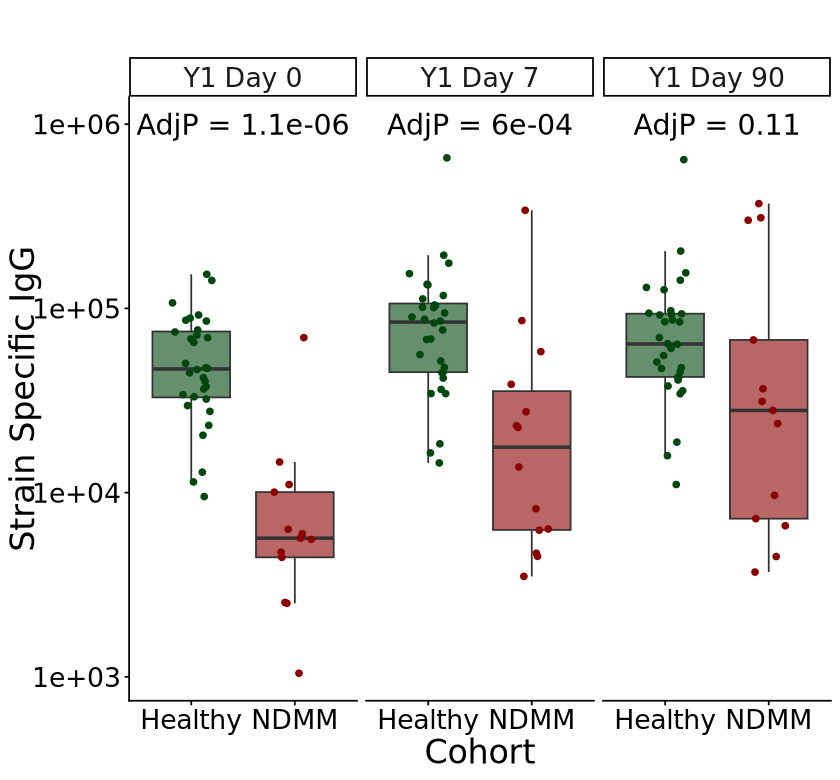

In [6]:
options(repr.plot.width = 7, repr.plot.height = 6.5)

flu_vax <- ggplot(
  subset1_mean,
  aes(
    x = Cohort,
    y = Value,
    fill = Cohort
  )
) +
  geom_boxplot(alpha = 0.6, outlier.shape = NA) + 
  geom_point(aes(color = Cohort), position = position_jitter(width = 0.2), size = 1.5) +
  facet_wrap(~Visit, ncol = 3) +
  scale_color_manual(values = cohort_color_map) +
  scale_fill_manual(values = cohort_color_map) +
  geom_text(
    data = p_table,
    aes(x = 1.5, y = y_pos, label = label),
    inherit.aes = FALSE,
    size = 6
  ) +
  scale_y_log10() +
  labs(
    x = "Cohort",
    y = "Strain Specific IgG",
    title = ""
  ) +
  theme_classic() +
  theme(text = element_text(size = 20), legend.position = "none")

flu_vax

ggsave("../../data/figure-outputs/figure-7/fig_7c.pdf", plot = flu_vax, width = 7, height = 6.5, dpi = 200, device = cairo_pdf)